# **LightGBM**

## **1. Import Libraries**

In [1]:
import lightgbm as lgb
import pandas as pd
import joblib 
from data_preparation import data_preparation

## **2. Data Preparation**

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = data_preparation('../dataset/digital_marketing_campaign_dataset.csv')

## **3. Preprocessing**

In [3]:
for df in [X_train, X_val, X_test]:
    df['CampaignType'] = df['CampaignType'].astype('category')

## **4. Hyperparameter Configuration**

In [4]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'max_depth': 2,
    'learning_rate': 0.001,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 110,
    'scale_pos_weight': len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
    'lambda_l1': 5,
    'lambda_l2': 5,
    'verbose': -1,
    'num_threads': -1
}


train_set = lgb.Dataset(X_train, label=y_train)
valid_set = lgb.Dataset(X_val, label=y_val, reference=train_set)

## **5. Training**

In [5]:
evals_result = {}

model = lgb.train(
    params,
    train_set,
    num_boost_round=8000,
    valid_sets=[train_set, valid_set],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=150, verbose=True),
        lgb.log_evaluation(100),
        lgb.record_evaluation(evals_result)
    ]
)

Training until validation scores don't improve for 150 rounds
[100]	train's auc: 0.725035	valid's auc: 0.703271
[200]	train's auc: 0.753246	valid's auc: 0.730911
[300]	train's auc: 0.769814	valid's auc: 0.755226
[400]	train's auc: 0.784055	valid's auc: 0.772033
[500]	train's auc: 0.790577	valid's auc: 0.780712
[600]	train's auc: 0.800865	valid's auc: 0.791323
[700]	train's auc: 0.806107	valid's auc: 0.798032
[800]	train's auc: 0.811708	valid's auc: 0.804672
[900]	train's auc: 0.814419	valid's auc: 0.808214
[1000]	train's auc: 0.816699	valid's auc: 0.811001
[1100]	train's auc: 0.819849	valid's auc: 0.813517
[1200]	train's auc: 0.822611	valid's auc: 0.816219
[1300]	train's auc: 0.824457	valid's auc: 0.818876
[1400]	train's auc: 0.826459	valid's auc: 0.82138
[1500]	train's auc: 0.828207	valid's auc: 0.823287
[1600]	train's auc: 0.82994	valid's auc: 0.824911
[1700]	train's auc: 0.830737	valid's auc: 0.825882
[1800]	train's auc: 0.831234	valid's auc: 0.826801
[1900]	train's auc: 0.831942	va

## **7. Predict testing dataset**

In [6]:
y_train_prob = model.predict(X_train).flatten()
y_test_prob  = model.predict(X_test).flatten()

## **8. Evaluate**

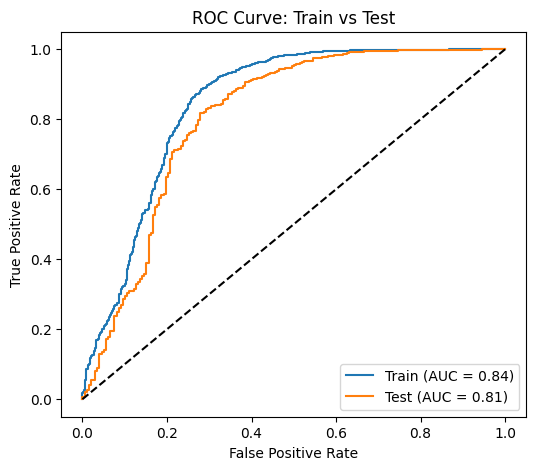

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_overfit(y_train, y_train_prob, y_test, y_test_prob):
    plt.figure(figsize=(6, 5))
    
    for y_true, y_prob, label in [(y_train, y_train_prob, 'Train'), (y_test, y_test_prob, 'Test')]:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--') 
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve: Train vs Test')
    plt.legend()
    plt.show()

plot_roc_overfit(y_train, y_train_prob, y_test, y_test_prob)

**Conclusion: No overfit, since the difference between AUC train and AUC test is not significant**